# Import

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

import seaborn as sns
from matplotlib.ticker import FuncFormatter

from sklearn.covariance import LedoitWolf

from matplotlib.gridspec import GridSpec
from scipy.optimize import minimize
#plt.style.use('seaborn-v0_8-darkgrid')
from dashboard import PortfolioDashboardVisualizer

In [2]:
data = pd.read_csv("data/benchmark_mids_cs.csv")

# Ensure the timestamp is datetime
data["time_stamp"] = pd.to_datetime(data["time_stamp"])

# Sort by ISIN and timestamp to get the correct last entry
data = data.sort_values(["isin", "time_stamp"])

# Keep the last observation per day per ISIN
data = data.groupby(["isin", data["time_stamp"].dt.date], as_index=False).last()
data["time_stamp"] = pd.to_datetime(data["time_stamp"].dt.date)
print(data.shape)
data.head()

(26622, 10)


,isin,Unnamed: 0,time_stamp,price,yield,country_iso,mat_cat,source,remaining_maturity,dv01
0,DE0001102366,2640,2015-01-01,104.3100,0.5400,DE,10,ref,9.618070,0.000957
1,DE0001102366,1980,2015-01-02,104.7105,0.4965,DE,10,ref,9.615332,0.000962
2,DE0001102366,1320,2015-01-05,104.5205,0.5165,DE,10,ref,9.607118,0.000959
3,DE0001102366,660,2015-01-06,105.2050,0.4450,DE,10,ref,9.604381,0.000966
4,DE0001102366,0,2015-01-07,104.8350,0.4835,DE,10,ref,9.601643,0.000961


In [3]:
# Parse timestamp BEFORE sorting/resampling
#data["time_stamp"] = pd.to_datetime(data["time_stamp"], utc=True)

# Consistent typing on mat_cat (string is safer for column labels)
data["mat_cat"] = data["mat_cat"].astype(str)
# Sort within each contract series
data = data.sort_values(["isin", "time_stamp"]).reset_index(drop=True)

# --- Δy by ISIN (no cross-ISIN leakage) ---
# If yield is in percent (e.g., 0.4835%), convert to decimal before differencing

y_level = data["yield"] / 100.0
data["dy"] = y_level.groupby(data["isin"]).diff()  # Δy in decimal (e.g., 1 bp = 0.0001)

# Also keep Δy in bp if needed
data["dy_bp"] = data["dy"] * 1e4  # basis points

# (Futures) We will build a *risk-normalized* return per unit DV01 next.
# For IR futures, linearized PnL ≈ - DV01 * Δy. Per unit DV01, return ≈ -Δy.
# This avoids notional/DV01 scaling headaches at optimization time.
data["r_per_DV01"] = -data["dy_bp"]*data["dv01"]  # per DV01 standardized return (dimensionless)
data["daily_coupon"] = data['yield'].shift(1)*(1/252)/100 #pour enlever le pourcent  
data["total_ret"] = data["r_per_DV01"] + data["daily_coupon"] 
data.head()

,isin,Unnamed: 0,time_stamp,price,yield,country_iso,mat_cat,source,remaining_maturity,dv01,dy,dy_bp,r_per_DV01,daily_coupon,total_ret
0,DE0001102366,2640,2015-01-01,104.3100,0.5400,DE,10,ref,9.618070,0.000957,NaN,NaN,NaN,NaN,NaN
1,DE0001102366,1980,2015-01-02,104.7105,0.4965,DE,10,ref,9.615332,0.000962,-0.000435,-4.35,0.004183,0.000021,0.004204
2,DE0001102366,1320,2015-01-05,104.5205,0.5165,DE,10,ref,9.607118,0.000959,0.000200,2.00,-0.001917,0.000020,-0.001898
3,DE0001102366,660,2015-01-06,105.2050,0.4450,DE,10,ref,9.604381,0.000966,-0.000715,-7.15,0.006904,0.000020,0.006924
4,DE0001102366,0,2015-01-07,104.8350,0.4835,DE,10,ref,9.601643,0.000961,0.000385,3.85,-0.003702,0.000018,-0.003684


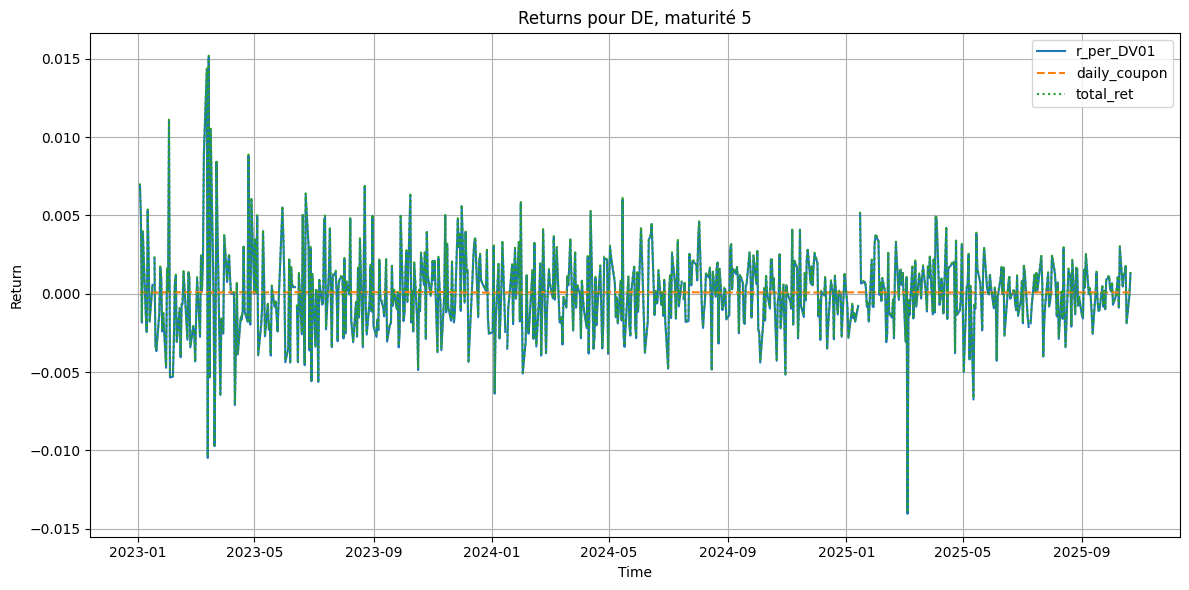

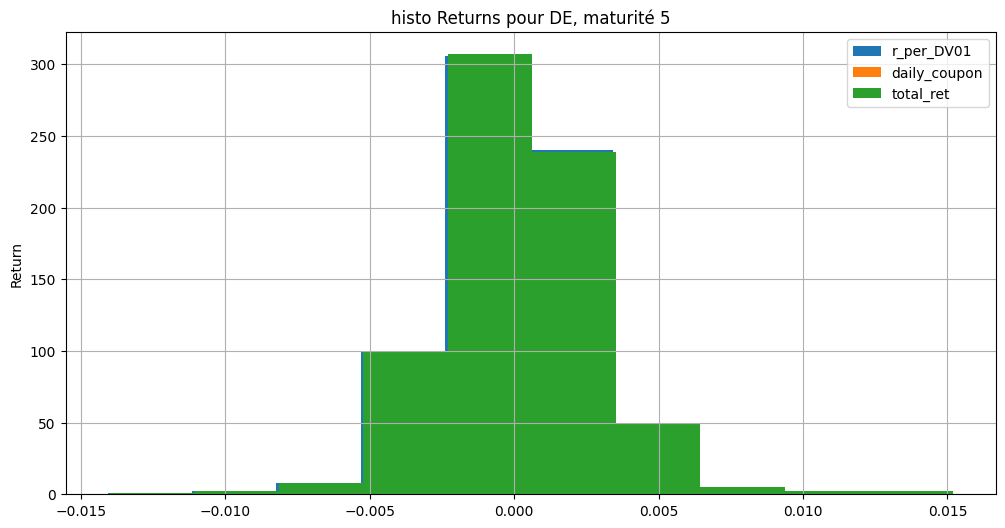

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# -----------------------------
# Variables à modifier facilement
# -----------------------------
country = "DE"                # Pays à filtrer
maturity = "5"                # Maturité à filtrer (valeur de mat_cat)
return_col1 = "r_per_DV01"   # Colonne de return DV01
return_col2 = "daily_coupon" # Colonne de coupon quotidien
return_col3 = "total_ret"    # Colonne de return total

start_date = "2023-01-01"    # Date de début du plot
end_date = "2025-12-31"      # Date de fin du plot

# -----------------------------
# Filtrage du DataFrame
# -----------------------------
df_plot = data.loc[
    (data["country_iso"] == country) &
    (data["mat_cat"] == maturity) &
    (data["time_stamp"] >= pd.to_datetime(start_date)) &
    (data["time_stamp"] <= pd.to_datetime(end_date))
]

# -----------------------------
# Plot avec matplotlib
# -----------------------------
plt.figure(figsize=(12,6))
plt.plot(df_plot["time_stamp"], df_plot[return_col1], label=return_col1, linestyle="-")
plt.plot(df_plot["time_stamp"], df_plot[return_col2], label=return_col2, linestyle="--")
plt.plot(df_plot["time_stamp"], df_plot[return_col3], label=return_col3, linestyle=":")
plt.title(f"Returns pour {country}, maturité {maturity}")
plt.xlabel("Time")
plt.ylabel("Return")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,6))
plt.hist(df_plot[return_col1], label=return_col1)
plt.hist(df_plot[return_col2], label=return_col2)
plt.hist(df_plot[return_col3], label=return_col3)
plt.title(f"histo Returns pour {country}, maturité {maturity}")
plt.ylabel("Return")
plt.legend()
plt.grid(True)
plt.show()

Bonne tête de return !

# Estimation des return

In [16]:
#On met data sous le bon format. Ce qu'on veut c'est :
# Date | Finacial product (ex FR_5 pour France bond mat 5) | Return
val = "total_ret"

data_completed = data[["time_stamp", "country_iso", "mat_cat", val]].copy()
data_completed["product"] = data_completed["country_iso"].astype(str) + "_" + data_completed["mat_cat"].astype(str)
data_completed = data_completed.drop(columns=["country_iso", "mat_cat"])
data_completed["time_stamp"] = pd.to_datetime(data_completed["time_stamp"])

data_completed.head()




,time_stamp,total_ret,product
0,2015-01-01,NaN,DE_10
1,2015-01-02,0.004204,DE_10
2,2015-01-05,-0.001898,DE_10
3,2015-01-06,0.006924,DE_10
4,2015-01-07,-0.003684,DE_10


# Ajout spread et curve 

In [25]:
def add_spread_curve(data):
    """
    Ajoute :
      1) Spreads entre pays à même maturité      : FR_DE_2 = FR_2 - DE_2
      2) Spreads intra-pays entre maturités      : FR_2_5  = FR_2 - FR_5

    Ajoute aussi une colonne "type" indiquant :
      - bond
      - spread_country
      - spread_curve

    data : DataFrame long (time_stamp, product, total_ret)
    return : DataFrame long enrichi
    """

    df = data.copy()

    # ----------------------------
    # Marquer les produits originaux
    # ----------------------------
    product_type = {p: "bond" for p in df["product"].unique()}

    # Extraire pays et maturités
    products = df["product"].unique()
    countries = sorted({p.split("_")[0] for p in products})
    maturities = sorted({p.split("_")[1] for p in products})

    # Pivot large : colonnes = produits
    wide = df.pivot(index="time_stamp", columns="product", values="total_ret").sort_index()

    # ----------------------------
    # 1) SPREADS ENTRE PAYS
    # ----------------------------
    for mat in maturities:
        prods_mat = [f"{c}_{mat}" for c in countries if f"{c}_{mat}" in wide.columns]

        for i in range(len(prods_mat)):
            for j in range(i + 1, len(prods_mat)):
                p1, p2 = prods_mat[i], prods_mat[j]
                c1, c2 = p1.split("_")[0], p2.split("_")[0]

                spread_name = f"{c1}_{c2}_{mat}"
                wide[spread_name] = wide[p1] - wide[p2]

                product_type[spread_name] = "spread_country"

    # ----------------------------
    # 2) SPREADS INTRA-PAYS
    # ----------------------------
    for c in countries:
        mats_c = sorted([p.split("_")[1] for p in products if p.startswith(c + "_")])

        for i in range(len(mats_c)):
            for j in range(i + 1, len(mats_c)):
                m1, m2 = mats_c[i], mats_c[j]
                p1, p2 = f"{c}_{m1}", f"{c}_{m2}"

                if p1 in wide.columns and p2 in wide.columns:
                    spread_name = f"{c}_{m1}_{m2}"
                    wide[spread_name] = wide[p1] - wide[p2]

                    product_type[spread_name] = "spread_curve"

    # ----------------------------
    # Retour au format long
    # ----------------------------
    long = wide.reset_index().melt(
        id_vars="time_stamp", 
        var_name="product", 
        value_name="total_ret"
    )

    # Ajouter la colonne type
    long["type"] = long["product"].map(product_type)

    return long

long = add_spread_curve(data_completed)
long.head(10)


,time_stamp,product,total_ret,type
0,2015-01-01,DE_10,NaN,bond
1,2015-01-02,DE_10,0.004204,bond
2,2015-01-05,DE_10,-0.001898,bond
3,2015-01-06,DE_10,0.006924,bond
4,2015-01-07,DE_10,-0.003684,bond
5,2015-01-08,DE_10,-0.002378,bond
6,2015-01-09,DE_10,0.002037,bond
7,2015-01-12,DE_10,0.000980,bond
8,2015-01-13,DE_10,0.000115,bond
9,2015-01-14,DE_10,0.005185,bond


# Class Portfolio à date t 

In [57]:
class Portfolio:
    def __init__(self, data, date, benchmark="ew", long_only=True, lamb=1.0, ridge=1e-3, window_days=None, sigma_level = 0.01, span = 60):
        """
        data: Pandas dataframe withe time_stamp, product, total_ret
        date: datetime-like
            Rebalance (estimation) date. Uses history up to and including this date.
        long_only: if True, project to simplex after solving (approximate).
        lamb: risk-aversion for mean-variance utility: maximize mu'w - lambda * w'Σw.
        ridge: diagonal shrinkage added to Σ for stability.
        window_days: if set, only use last N calendar days of history for μ, Σ.
        """
        self.data = data
        self.date = pd.to_datetime(date)
        self.benchmark = benchmark
        self.returns = None
        self.mean_returns = None
        self.cov_matrix = None
        self.weights = None

        self.long_only = long_only
        self.lamb = float(lamb)
        self.ridge = float(ridge)
        self.window_days = window_days
        self.benchmark_weights = None
        self.sigma_level = sigma_level
        self.span = span

    def get_returns_until(self):
        """filter up to self.date."""
        R = self.data[self.data["time_stamp"] < self.date]

        if self.window_days is not None:
            start_cut  = self.date - pd.Timedelta(days=int(self.window_days))
            R = R[R["time_stamp"] >= start_cut]
        #print(R)
        # Do not drop to full intersection early; compute pairwise μ, Σ
        self.returns = R

    def estimate_returns(self):
        """EWMA (exponential weighted mean) of returns per product."""
        span=self.span #Span control the half life

        # on prend seulement date, produit et return
        df = self.returns[["time_stamp", "product", "total_ret"]].copy()
        df = df.sort_values(["product", "time_stamp"])
        

        # EWMA par produit
        ewma = (
            df.groupby("product")["total_ret"]
            .apply(lambda x: x.ewm(span=span, adjust=False).mean().iloc[-1])
            .reset_index(name="ewma_return")
        )
        

        self.mean_returns = ewma

    def estimate_cov_matrix(self):
        """
        EWMA covariance (RiskMetrics) + shrinkage toward diagonal.
        """
        l= (self.span -1)/(self.span +1)
        shrink=0.1 

        panel = self.returns.pivot(
            index="time_stamp",
            columns="product",
            values="total_ret"
        ).sort_index()

        X = panel.fillna(0).values
        n, k = X.shape

        # initial covariance
        Sigma = np.cov(X, rowvar=False)

        # EWMA recursion
        for t in range(n):
            r = X[t].reshape(-1, 1)
            Sigma = l * Sigma + (1 - l) * (r @ r.T)

        # shrinkage toward diag
        diag = np.diag(np.diag(Sigma))
        Sigma = (1 - shrink) * Sigma + shrink * diag

        self.cov_matrix =  pd.DataFrame(Sigma, index=panel.columns, columns=panel.columns)

    def markowitz2(self, lambda_risk=None, w_prev=None):
        """
        Optimisation Markowitz classique avec long-only et risque intégré dans l'objectif.

        max w.T @ mean_returns - lambda_risk * w.T @ cov_matrix @ w
        s.t. sum(w) = 1, wi >= 0 si long_only

        Arguments :
            lambda_risk : float, trade-off risque/rendement (si None, prend self.lamb)
            w_prev      : array, poids du portefeuille précédent pour warm-start

        Retourne :
            self.weights : DataFrame des poids optimaux
        """
        mean_returns = self.mean_returns["ewma_return"]
        cov_matrix = self.cov_matrix.values
        n = len(mean_returns)
        long_only = self.long_only
        lambda_risk = self.lamb
        

        # Fonction objectif (à minimiser)
        def objective(w):
            # On minimise -[E[R] - λ Var(R)] = λ w.T Σ w - w.T μ
            return lambda_risk * w @ cov_matrix @ w - w @ mean_returns

        # Gradient analytique
        def grad_objective(w):
            return 2 * lambda_risk * cov_matrix @ w - mean_returns

        # Contraintes : somme des poids = 1
        constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1,
                        'jac': lambda w: np.ones_like(w)}]
        
        # Bornes
        bounds = [(0, 1) if long_only else (-0.5, 2)] * n

        # Initial guess
        if w_prev is not None:
            w0 = np.clip(w_prev.values.flatten(), 0, 1) if long_only else w_prev.values.flatten()
            w0 = w0 / np.sum(w0)  # normalisation pour somme = 1
        else:
            w0 = np.ones(n) / n

        # Minimisation
        res = minimize(objective, w0, jac=grad_objective,
                    bounds=bounds, constraints=constraints,
                    method='SLSQP', options={'ftol':1e-9, 'disp':False, 'maxiter':1000})

        if not res.success:
            raise ValueError("Optimisation échouée : " + res.message)

        # Résultat
        weights_opt = res.x
        self.weights = pd.DataFrame(weights_opt, index=self.mean_returns["product"], columns=[self.date])
        return self.weights


    def benchmark_w(self):
        n = len(self.mean_returns)
        if self.benchmark == "ew":
            self.benchmark_weights = pd.DataFrame(np.ones(n) / n,index=self.mean_returns["product"], columns=[self.date])
        else:
            raise NotImplementedError("Only 'ew' benchmark implemented for now.")

    def process(self):
        self.get_returns_until()
        self.estimate_returns()
        self.estimate_cov_matrix()
        self.markowitz2() #paramètre très sensible
        self.benchmark_w()
        return self.weights


In [50]:
date = "2023-06-01"


pf = Portfolio(long, date, benchmark="ew", long_only=True, window_days=200,lamb=100)
#print(pf.returns)
w = pf.process() 
#print(pf.mean_returns)
print(w)

            2023-06-01
product               
DE_10     6.631074e-19
DE_10_15  3.888846e-18
DE_10_2   7.361536e-18
DE_10_30  3.379764e-02
DE_10_5   6.393078e-18
DE_15     0.000000e+00
DE_15_2   0.000000e+00
DE_15_30  2.753889e-02
DE_15_5   1.020532e-18
DE_2      7.849784e-19
DE_2_30   1.830753e-18
DE_2_5    3.961123e-19
DE_30     6.018123e-19
DE_30_5   0.000000e+00
DE_5      0.000000e+00
DE_FR_10  5.782775e-19
DE_FR_15  2.409883e-18
DE_FR_2   1.581848e-19
DE_FR_30  0.000000e+00
DE_FR_5   2.351843e-18
DE_IT_10  0.000000e+00
DE_IT_15  0.000000e+00
DE_IT_2   7.502729e-19
DE_IT_30  0.000000e+00
DE_IT_5   0.000000e+00
FR_10     2.769966e-18
FR_10_15  0.000000e+00
FR_10_2   3.536062e-18
FR_10_30  1.102656e-01
FR_10_5   1.438207e-18
FR_15     3.966376e-18
FR_15_2   2.826084e-19
FR_15_30  7.293219e-18
FR_15_5   1.284756e-18
FR_2      8.844466e-19
FR_2_30   4.464708e-19
FR_2_5    1.885468e-18
FR_30     0.000000e+00
FR_30_5   0.000000e+00
FR_5      4.521002e-18
FR_IT_10  0.000000e+00
FR_IT_15  0

# Creation du time series portfolio

In [55]:
class TimeSeriesPortfolio:
    def __init__(self, data, start_date, end_date, rebalance_freq='1M',
                 long_only=False, lamb=1.0, benchmark="ew", ridge=1e-3,
                 window_days=None, sigma_level=0.01, capital_init=100_000, span = 60):

        # Convert time_stamp to Timestamp
        self.data = data.copy()
        self.data["time_stamp"] = pd.to_datetime(self.data["time_stamp"])
        self.start_date = pd.to_datetime(start_date)
        self.end_date = pd.to_datetime(end_date)
        self.rebalance_freq = rebalance_freq
        self.long_only = long_only
        self.lamb = float(lamb)
        self.benchmark = benchmark
        self.ridge = float(ridge)
        self.window_days = window_days
        self.sigma_level = sigma_level
        self.capital_init = capital_init
        self.span = span

        self.rebalance_dates = None
        self.all_dates = None
        self.weights_history = pd.DataFrame()
        self.exposures_history = pd.DataFrame()
        self.portfolio_returns = pd.Series(dtype=float)
        self.benchmark_returns = pd.Series(dtype=float)
        self.metrics = {}


        # Filter data for rolling window
        start_window = self.start_date - pd.Timedelta(days=5_000)
        self.R = self.data[
            (self.data["time_stamp"] >= start_window) &
            (self.data["time_stamp"] <= self.end_date)
        ]

    def freq_to_pd_freq(self):
        f = self.rebalance_freq.upper()
        if f.endswith(('D', 'B', 'W', 'M')):
            return f
        return '1M'

    def generate_rebalance_dates(self):
        all_dates = pd.DatetimeIndex(self.R["time_stamp"].unique())
        mask = (all_dates >= self.start_date) & (all_dates <= self.end_date)
        all_dates = all_dates[mask].sort_values()
        self.all_dates = all_dates

        if len(all_dates) == 0:
            raise ValueError("No market dates in the selected window.")

        targets = pd.date_range(start=self.start_date, end=self.end_date,
                                freq=self.freq_to_pd_freq())
        reb = []
        for tgt in targets:
            tgt = pd.Timestamp(tgt)  # assure tz-naive Timestamp
            pos = all_dates.searchsorted(tgt)
            if pos < len(all_dates):
                d = all_dates[pos]
                if (len(reb) == 0) or (d != reb[-1]):
                    reb.append(d)

        if all_dates[-1] not in reb:
            reb.append(all_dates[-1])

        self.rebalance_dates = pd.DatetimeIndex(reb)

    def generate_portfolios(self):
        if self.rebalance_dates is None or self.all_dates is None:
            self.generate_rebalance_dates()

        weights_list = []
        exposures_list = []

        pf_returns_pct = []
        bm_returns_pct = []
        returns_dates = []

        pf_pnl_daily = []
        bm_pnl_daily = []

        capital = self.capital_init
        current_value = capital
        current_value_bm = capital

        for i, t in enumerate(self.rebalance_dates[:-1]):
            t_next = self.rebalance_dates[i + 1]
            pf = Portfolio(
                data=self.data,
                date=t,
                benchmark=self.benchmark,
                long_only=self.long_only,
                lamb=self.lamb,
                ridge=self.ridge,
                window_days=self.window_days,
                sigma_level=self.sigma_level,
                span = self.span
            )
            
            w_df = pf.process()
            w = w_df.iloc[:, 0]
            cols = w.index.tolist()


            # Benchmark weights
            w_bm = pf.benchmark_weights.reindex(cols).iloc[:, 0].fillna(0.0)
            # Exposure normalization
            target_dv01 = self.capital_init
            exposure = w * (target_dv01 / np.sum(np.abs(w))) if np.sum(np.abs(w)) != 0 else w.copy()
            exposure_bm = w_bm * (target_dv01 / np.sum(np.abs(w_bm))) if np.sum(np.abs(w_bm)) != 0 else w_bm.copy()

            # Slice returns
            
            # --- 2. Filtrer R pour la période ---
            period_mask = (self.R["time_stamp"] > t) & (self.R["time_stamp"] <= t_next)
            R_slice_long = self.R.loc[period_mask].copy()

            # --- 3. Pivot pour obtenir dates x produits ---
            R_slice = R_slice_long.pivot(index="time_stamp", columns="product", values="total_ret")

            # --- 4. Ne garder que les produits pour lesquels on a des poids ---
            products_in_w = [p for p in w.index if p in R_slice.columns]
            R_slice = R_slice[products_in_w]

            # --- 5. Remplacer les NaN par 0 ---
            R_slice = R_slice.fillna(0.0)


            # PnL per day
            pf_pnl_day = R_slice.values @ exposure[products_in_w].values
            bm_pnl_day = R_slice.values @ exposure_bm[products_in_w].values

            pf_pnl_daily.extend(pf_pnl_day)
            bm_pnl_daily.extend(bm_pnl_day)

            pf_returns_pct.extend((pf_pnl_day / current_value).tolist())
            bm_returns_pct.extend((bm_pnl_day / current_value_bm).tolist())
            returns_dates.extend(R_slice.index.tolist())

            current_value += pf_pnl_day.sum()
            current_value_bm += bm_pnl_day.sum()

            weights_list.append(w.values)
            exposures_list.append(exposure.values)

        asset_names = w.index if 'w' in locals() else [f"a{i}" for i in range(len(weights_list[0]))]
        self.weights_history = pd.DataFrame(weights_list, index=self.rebalance_dates[:-1], columns=asset_names)
        self.exposures_history = pd.DataFrame(exposures_list, index=self.rebalance_dates[:-1], columns=asset_names)

        if len(returns_dates) > 0:
            self.portfolio_returns = pd.Series(pf_returns_pct, index=pd.DatetimeIndex(returns_dates))
            self.benchmark_returns = pd.Series(bm_returns_pct, index=pd.DatetimeIndex(returns_dates))

        # Cumulative return
        pf_cum_return = (1 + self.portfolio_returns.fillna(0)).cumprod()
        bm_cum_return = (1 + self.benchmark_returns.fillna(0)).cumprod()

        # Cumulative PnL
        pf_value = pd.Series(capital + np.array(pf_pnl_daily).cumsum(), index=pd.DatetimeIndex(returns_dates))
        bm_value = pd.Series(capital + np.array(bm_pnl_daily).cumsum(), index=pd.DatetimeIndex(returns_dates))
        pf_pnl = pd.Series(pf_pnl_daily, index=pd.DatetimeIndex(returns_dates))
        bm_pnl = pd.Series(bm_pnl_daily, index=pd.DatetimeIndex(returns_dates))

        trading_days = 252
        pf_mean = self.portfolio_returns.mean()
        pf_std = self.portfolio_returns.std()
        pf_sharpe = (pf_mean / pf_std * np.sqrt(trading_days)) if pf_std != 0 else np.nan

        # Metrics
        roll_max = pf_value.cummax() if len(pf_value) > 0 else pd.Series(dtype=float)
        dd = (pf_value - roll_max) / roll_max if len(pf_value) > 0 else pd.Series(dtype=float)

        self.metrics = {
            "initial_capital": capital,
            "portfolio_value": pf_value,
            "benchmark_value": bm_value,
            "portfolio_pnl": pf_pnl,
            "benchmark_pnl": bm_pnl,
            "pf_cumulative_return": pf_cum_return,
            "bm_cumulative_return": bm_cum_return,
            "mean_return": pf_mean,
            "volatility": pf_std,
            "sharpe": pf_sharpe,
            "gross_exposure": np.abs(self.exposures_history).sum(axis=1),
            "net_exposure": self.exposures_history.sum(axis=1),
            "drawdown": dd,
            "max_drawdown": dd.min() if len(dd) > 0 else np.nan
        }

        print("Tout a marché !!")
    
    def exposition_by_country(self):
        #assuming the bonds product are FR_..
        df = self.exposures_history.copy()

        # extraire le code pays (les 2 premiers caractères) pour chaque colonne
        country_codes = df.columns.str[:2]

        # somme par pays via groupby sur l’axis=1
        expo_by_country = df.groupby(country_codes, axis=1).sum()

        return expo_by_country

    def exposition_by_mat(self):
        #assuming the bonds product are FR_..
        df = self.exposures_history.copy()

        # extraire le code pays (les 2 premiers caractères) pour chaque colonne
        mat = df.columns.str[3:]

        # somme par pays via groupby sur l’axis=1
        expo_by_mat = df.groupby(mat, axis=1).sum()

        return expo_by_mat
        


Tout a marché !!


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
c:\Users\hugoj\Documents\QF_project\Project_QuantFox\dashboard.py:460: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  plt.tight_layout()


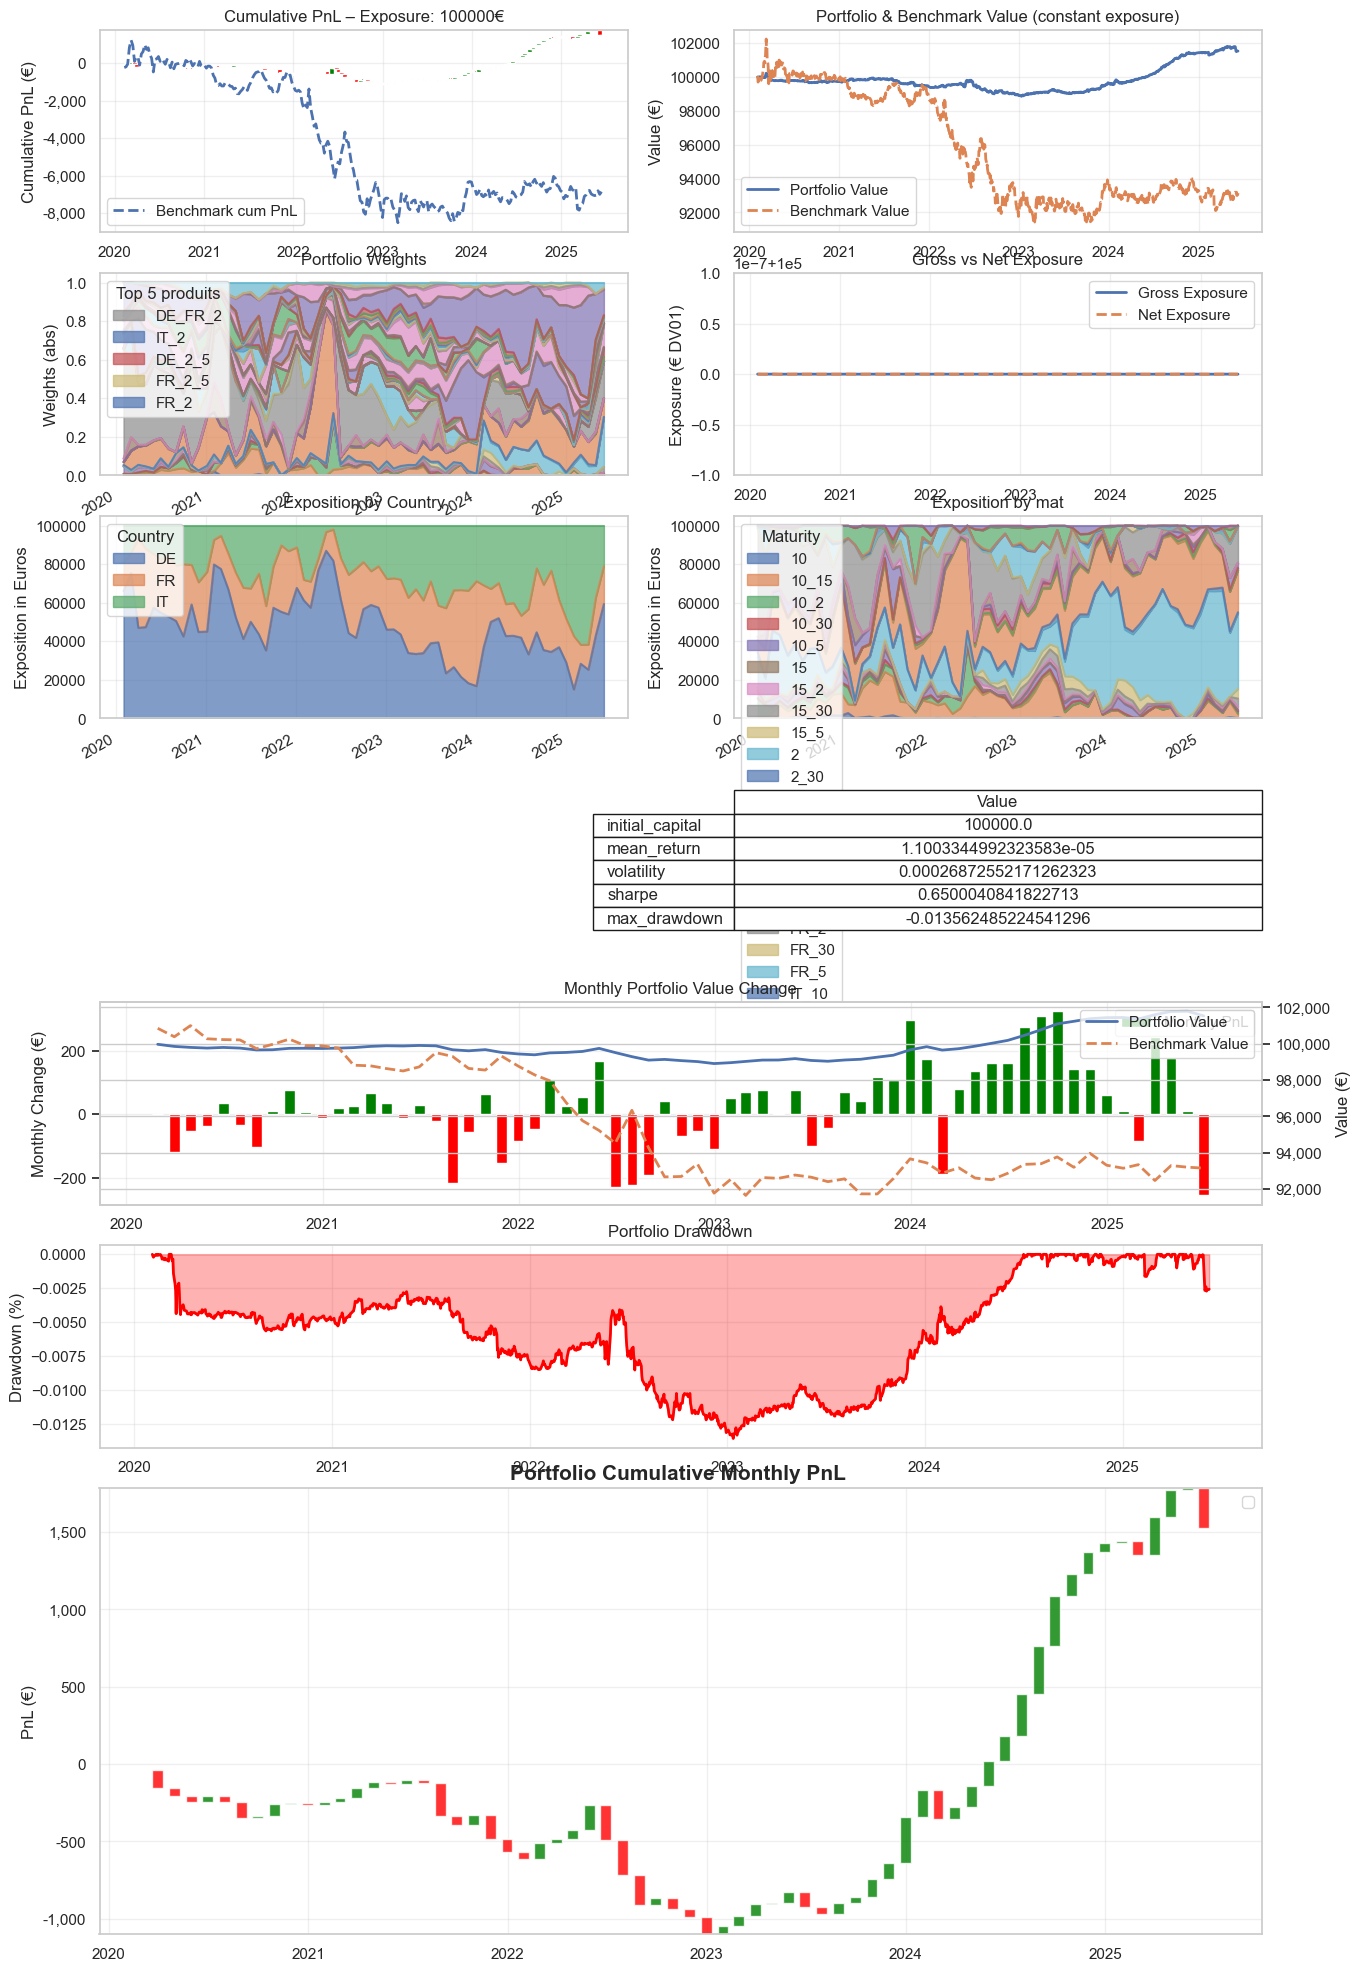

In [75]:
start_date = "2020-01-01"
end_date   = "2025-06-10"


tspf = TimeSeriesPortfolio(
    #data_completed,
    long,
    start_date,
    end_date,
    rebalance_freq="1M",
    long_only=True,
    lamb=1000,
    benchmark="ew",
    window_days=1000,  # à enlever
    span = 60 # demi vie de nos données contrôle la réactivité de notre modèle
    )

tspf.generate_portfolios()

viz = PortfolioDashboardVisualizer(tspf)
viz.plot_dashboard()